In [115]:
import pandas as pd

# load dataset :
df = pd.read_csv("../data/Spotify_Tracks.csv")

# Basic sanity check :
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [116]:
# shape of data :
df.shape

(232725, 18)

In [117]:
# columns name :
df.columns

Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='str')

In [118]:
# data types & missing values :
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  str    
 1   artist_name       232725 non-null  str    
 2   track_name        232724 non-null  str    
 3   track_id          232725 non-null  str    
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  str    
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  str    
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    232725 non-nu

In [119]:
# quick stats :
df.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [120]:
# TO CHECK DATA QUALITY :
# === missing values per columns ===
df.isna().sum().sort_values(ascending=False)

track_name          1
genre               0
artist_name         0
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

In [121]:
# DUPILCATED ROWS :
df.duplicated().sum()

np.int64(0)

In [122]:
#  POPULARITY sanity check :
df["popularity"].describe()

df["popularity"].value_counts().head(10)

popularity
0     6312
50    5415
53    5414
51    5401
52    5342
49    5266
48    5068
54    5013
47    4944
55    4696
Name: count, dtype: int64

In [123]:
#==== SEGMENT A : EMERGING / ACTIVE TRACKS 
active_df = df[df["popularity"]>0]
active_df.shape

# comparing popularity distribution
active_df["popularity"].describe()



count    226413.000000
mean         42.274066
std          17.077129
min           1.000000
25%          30.000000
50%          44.000000
75%          55.000000
max         100.000000
Name: popularity, dtype: float64

In [124]:
# STEP 1 : Deriving a New column - POPULARITY LEVEL

# CORE ANALYSIS | QUES : Do audio features systematically changes as popularity increases ?
# popularity bucket :
def popularity_bucket(p):
    if p < 30 :
        return "Low" 
    elif p < 60 :
        return "Medium"
    else :
        return "High"

active_df["popularity_level"] = active_df["popularity"].apply(popularity_bucket)

active_df["popularity_level"].value_counts()

popularity_level
Medium    135932
Low        54027
High       36454
Name: count, dtype: int64

In [125]:
# STEP 2 : COMPARING AUDIO FEATURES ACROSS POPULARITY LEVELS
audio_features = [
    "danceability","energy","acousticness","speechiness","valence","tempo","loudness"
]
active_df.groupby("popularity_level")[audio_features].mean()

,danceability,energy,acousticness,speechiness,valence,tempo,loudness
popularity_level,,,,,,,
High,0.630130,0.640634,0.227710,0.107316,0.487068,120.486763,-6.930294
Low,0.487086,0.512091,0.541733,0.195847,0.426709,113.862142,-12.098718
Medium,0.560036,0.585802,0.323485,0.094601,0.453787,118.507015,-9.065222


REANCHORING OUR GOAL :
QUES : Are there Medium-POP tracks that already look like High-POP tracks ? 
Those will be our EMERGING TRENDING TRACKS

In [126]:
# HERE WE ARE GONNA CHECK WHAT MAKES A TRACK HIGH POP :
high_profile = (active_df[active_df["popularity_level"]=="High"]
                [["energy","danceability","acousticness"]].mean())

print("BENCHMARK FOR A HIGH POP TRACK :")
high_profile


BENCHMARK FOR A HIGH POP TRACK :


energy          0.640634
danceability    0.630130
acousticness    0.227710
dtype: float64

In [127]:
# NOW ISOLATING MEDIUM POP TRACKS :

medium_df = active_df[active_df["popularity_level"]=="Medium"]
medium_df.shape

(135932, 19)

DEFINING WHAT AN "EMERGING" TRACKS IS :
ENERGY >= AVG. HIGH ENERGY 
DANCEABILITY >= AVG. HIGH DANCEABILITY
ACOUSTICNESS <= AVG. HIGH ACOUSTICNESS

In [128]:
emerging_df = medium_df[
    (medium_df["energy"] >= high_profile["energy"]) &
    (medium_df["danceability"] >= high_profile["danceability"]) &
    (medium_df["acousticness"] <= high_profile["acousticness"]) 
]
emerging_df.shape

(18903, 19)

In [129]:
# INSPECTING WHAT WE HAVE FOUND :
emerging_df[
    ["track_name", "artist_name", "popularity", 
     "energy", "danceability", "acousticness"]
].head(10)


,track_name,artist_name,popularity,energy,danceability,acousticness
701,King of the Pines (feat. Upchurch),Tommy Chayne,44,0.808,0.734,0.01810
703,Sugar Daddy,Pistol Annies,43,0.870,0.647,0.00761
718,About To,Adam Sanders,42,0.668,0.635,0.02710
740,Boy Gets A Truck,Keith Urban,44,0.693,0.648,0.00667
751,Back That Thing Up,Justin Moore,41,0.896,0.679,0.04740
755,Let It Ride,Bachman-Turner Overdrive,52,0.781,0.632,0.15700
765,One Way Ticket (Because I Can),LeAnn Rimes,44,0.778,0.696,0.02910
766,Where I Come From (Remix) [feat. Colt Ford & T...,Montgomery Gentry,42,0.750,0.756,0.03890
772,"Chicks, Trucks, and Beer - feat. Colt Ford",Tyler Farr,43,0.915,0.637,0.01250
774,The Wind - Greatest Hits Version,Zac Brown Band,44,0.948,0.691,0.20500


In [130]:
# HERE ARE GONNA FIND OUT WHAT % OF TRACKS ARE EMERGING :
percent_emerging=len(emerging_df)/len(medium_df) * 100

print(f"OUT OF ~135000 TRACKS ONLY {percent_emerging} % TRACKS SHOW SOUND CHARACTERISTIC OF HIGH POP TRACKS")

emerging_df.columns


OUT OF ~135000 TRACKS ONLY 13.906217814789748 % TRACKS SHOW SOUND CHARACTERISTIC OF HIGH POP TRACKS


Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence',
       'popularity_level'],
      dtype='str')

GOAL : TO LOCATE ARTISTS WHO CONSISTENTLY APPEAR IN EMERGING TRACKS 
OUTCOME : WE COULD INTERPRET THAT THESES ARTISTS COULD GO MAINSTREAM (LIKELY)

In [131]:
# HERE WE ARE IDENTIFYING WHICH ARTISTS SHOW UP CONSITENTLY IN OUR DATASET :

artists_emerging_counts = (emerging_df["artist_name"].value_counts().reset_index())

artists_emerging_counts.columns = ["artist_name" , "emerging_track_count"]

artists_emerging_counts.head(10)

,artist_name,emerging_track_count
0,Daddy Yankee,105
1,Wisin & Yandel,86
2,Jamiroquai,71
3,Thievery Corporation,66
4,Gramatik,65
5,Upchurch,61
6,Eminem,60
7,Rebelution,57
8,Don Omar,56
9,Chris Brown,55


In [132]:
# NOW WE ARE GONNA FILTER OUT OUR TRUE EMERGING ARTISTS :
emerging_artists = artists_emerging_counts[artists_emerging_counts["emerging_track_count"] >= 10 ]

emerging_artists_sorted = emerging_artists.sort_values(by="emerging_track_count" , ascending=True)

In [133]:
 # QUES : WHAT IS AVG POP OF TRACKS FOR EACH EMERGING TRACKS ?
artists_pop_validation = (
    emerging_df.groupby("artist_name")["popularity"].mean().reset_index()
)
artists_pop_validation.columns = ["artist_name","avg_popularity"]
artists_pop_validation.head(10)

,artist_name,avg_popularity
0,!!!,39.933333
1,$tupid Young,58.000000
2,$uicideBoy$,54.027027
3,(Hed) P.E.,43.000000
4,*NSYNC,52.250000
5,03 Greedo,59.000000
6,10 Ft. Ganja Plant,37.000000
7,11 Acorn Lane,40.000000
8,112,56.833333
9,116,49.500000


In [134]:
# MERGING WITH EMERGING ARTISTS COUNT :
emerging_artists_summary = emerging_artists_sorted.merge(
    artists_pop_validation,on="artist_name",how="left"
)
emerging_artists_summary

,artist_name,emerging_track_count,avg_popularity
0,Eloy,10,37.000000
1,Olga Tanon,10,35.000000
2,Ilegales,10,39.500000
3,Mýa,10,49.900000
4,Huey Lewis & The News,10,50.900000
...,...,...,...
481,Gramatik,65,40.076923
482,Thievery Corporation,66,37.772727
483,Jamiroquai,71,46.056338
484,Wisin & Yandel,86,41.430233


HERE WE ARE GONNA FIND THE TRUE EMERGING ARTISTS :
CONDITION TO SATISTFY : 1. EMERGING_TRACK_COUNT >= 10 
                        2. AVG_POP < 60

In [135]:
true_emerging_artist = emerging_artists_summary[
    emerging_artists_summary["avg_popularity"] < 60 
]

true_emerging_artist.sort_values(by="emerging_track_count",ascending=False).head(10)

,artist_name,emerging_track_count,avg_popularity
485,Daddy Yankee,105,41.457143
484,Wisin & Yandel,86,41.430233
483,Jamiroquai,71,46.056338
482,Thievery Corporation,66,37.772727
481,Gramatik,65,40.076923
480,Upchurch,61,50.147541
479,Eminem,60,55.900000
478,Rebelution,57,46.982456
477,Don Omar,56,46.678571
476,Chris Brown,55,51.854545


HERE ARE THE VISUALS TO BACK MY ANALYSIS : THIS CHART ANSWER -- AS POPULARITY INCREASES DOES ACOUSTICNESS DECREASES 

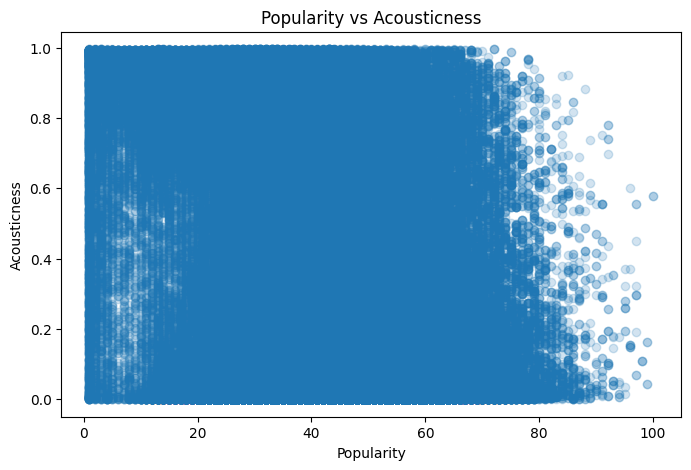

In [136]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8,5))

plt.scatter(
    active_df["popularity"],
    active_df["acousticness"],
    alpha=0.2
)

plt.xlabel("Popularity")
plt.ylabel("Acousticness")
plt.title("Popularity vs Acousticness")

plt.show()

THIS CHART WILL ANSWER : DO EMERGING TRACKS ACTUALLY RESEMBLE HIGH-POPULARITY TRACKS ?

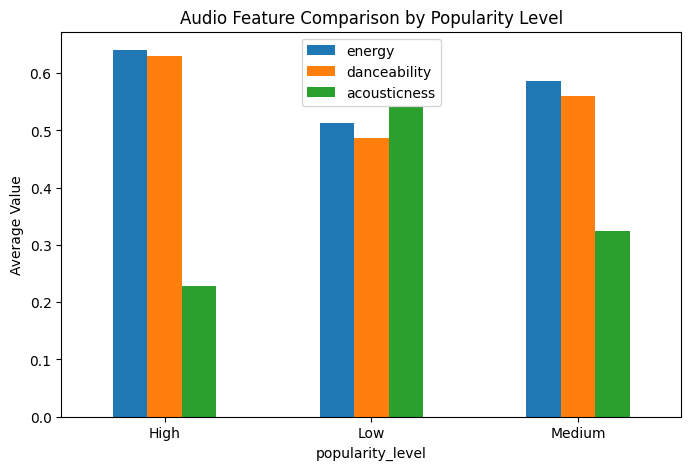

In [137]:
# CREATING A COMPARISON TABLE : 

comparison_df = active_df.groupby("popularity_level")[
    ["energy", "danceability", "acousticness"]
].mean()

comparison_df

# Creating BAR CHART :

comparison_df.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Audio Feature Comparison by Popularity Level")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.show()


THIS CHART ANSWERS : WHICH ARTIST SHOWS STRONGEST EMERGING MOMENTUM 

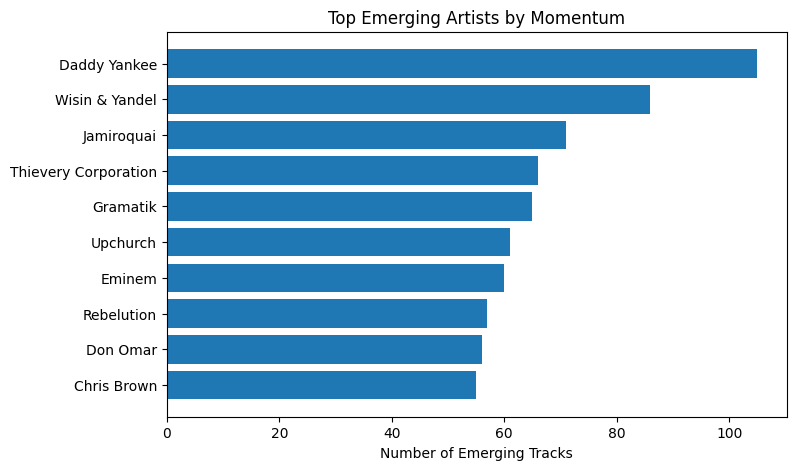

In [140]:
# CREATING TOP ARTISTS :

top_emerging_artists = true_emerging_artist.sort_values(
    by="emerging_track_count",
    ascending=False
).head(10)

# PLOTTING THE GRAPH :

plt.figure(figsize=(8, 5))

plt.barh(
    top_emerging_artists["artist_name"],
    top_emerging_artists["emerging_track_count"]
)

plt.xlabel("Number of Emerging Tracks")
plt.title("Top Emerging Artists by Momentum")

plt.gca().invert_yaxis()
plt.show()
